# Leave-One-Site-Out (LOSO) Cross-Validation for GPR

This notebook evaluates the baseline GPR model using leave-one-site-out cross-validation.

**Why LOSO?**
- Tests the model's ability to predict at locations it hasn't seen
- More realistic for the use case of predicting PM2.5 at unmonitored locations
- Avoids data leakage from same-site observations in train/test

**Procedure:**
1. For each site, hold out all its observations
2. Train GP on remaining sites
3. Predict on held-out site
4. Aggregate metrics across all folds

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import torch
import gpytorch
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from tqdm import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

# Import timing utilities
from timing_utils import TimingLogger, Timer

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize timing logger
timing_log = TimingLogger("../timings/gpr_timings.csv", experiment_name="loso_cv")
print("Timing will be logged to timings/gpr_timings.csv")

/home/vcaristo/miniconda3/envs/patel/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Timing will be logged to timings/gpr_timings.csv


## 1. Load and Prepare Data

Same preprocessing as baseline notebook.

In [2]:
# Load datasets
pm_all = pd.read_csv("../../data/pm25_data_complete_2003-2021_nodups_051922.csv", low_memory=False)
pm_fixed = pd.read_csv('../../eda/pm25_locs_with_states.csv')

# Filter to Montana
mt_sites = pm_fixed[pm_fixed['state'] == 'MT'].copy()
mt_ll_ids = set(mt_sites['ll_id'].values)

# Parse date and filter to 2019
pm_all['date'] = pd.to_datetime(pm_all['date'], format='%Y%m%d')
pm_all['year'] = pm_all['date'].dt.year
pm_mt = pm_all[(pm_all['ll_id'].isin(mt_ll_ids)) & (pm_all['year'] == 2019)].copy()

print(f"Montana 2019: {len(pm_mt):,} observations from {pm_mt['ll_id'].nunique()} sites")

Montana 2019: 8,043 observations from 32 sites


In [3]:
# Define features
time_varying_features = ['aot', 'wind', 'hgt', 'cld', 'longwave', 'rh', 'tmax', 'cadI', 'smogP']
static_features = ['lat', 'lon', 'logpd2500g', 'minf_5000', 'sd50k', 
                   'heavy_industrial_ind1', 'housing']

available_tv = [f for f in time_varying_features if f in pm_mt.columns]
available_static = [f for f in static_features if f in mt_sites.columns]

# Merge datasets
pm_mt_subset = pm_mt[['ll_id', 'date', 'pm25'] + available_tv].copy()
mt_static = mt_sites[['ll_id'] + available_static].copy()
df = pm_mt_subset.merge(mt_static, on='ll_id', how='left')

# Define final feature columns
feature_cols = available_tv + available_static

# Clean data
df_clean = df.dropna(subset=feature_cols + ['pm25']).copy()
print(f"Clean data: {len(df_clean):,} observations")
print(f"Features: {feature_cols}")

Clean data: 7,551 observations
Features: ['aot', 'wind', 'hgt', 'cld', 'longwave', 'rh', 'tmax', 'cadI', 'smogP', 'lat', 'lon', 'logpd2500g', 'minf_5000', 'sd50k', 'heavy_industrial_ind1', 'housing']


In [4]:
# Check observations per site
site_counts = df_clean.groupby('ll_id').size().sort_values(ascending=False)
print(f"Observations per site:")
print(f"  Min: {site_counts.min()}")
print(f"  Max: {site_counts.max()}")
print(f"  Mean: {site_counts.mean():.1f}")
print(f"  Median: {site_counts.median():.1f}")
print(f"\nSites with <50 observations: {(site_counts < 50).sum()}")

Observations per site:
  Min: 93
  Max: 365
  Mean: 269.7
  Median: 359.0

Sites with <50 observations: 0


## 2. Define GP Model

In [5]:
class ExactGPModel(gpytorch.models.ExactGP):
    """Exact GP model with RBF kernel + ARD."""
    
    def __init__(self, train_x, train_y, likelihood, n_features):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=n_features)
        )
    
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [6]:
def train_gp(train_x, train_y, n_features, n_epochs=50, lr=0.1, verbose=False):
    """Train a GP model and return it."""
    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
    model = ExactGPModel(train_x, train_y, likelihood, n_features).to(device)
    
    model.train()
    likelihood.train()
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    
    for i in range(n_epochs):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
        
        if verbose and (i + 1) % 20 == 0:
            print(f"  Epoch {i+1}, Loss: {loss.item():.4f}")
    
    return model, likelihood

In [7]:
def predict_gp(model, likelihood, test_x):
    """Make predictions with a trained GP."""
    model.eval()
    likelihood.eval()
    
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred = likelihood(model(test_x))
        return pred.mean.cpu().numpy(), pred.variance.cpu().numpy()

## 3. Run LOSO Cross-Validation

In [8]:
# Settings
MAX_TRAIN_SIZE = 2000  # Subsample training data for tractability
N_EPOCHS = 50

# Get unique sites
sites = df_clean['ll_id'].unique()
n_sites = len(sites)
print(f"Running LOSO CV across {n_sites} sites...")

Running LOSO CV across 28 sites...


In [9]:
# Storage for results
all_predictions = []
all_actuals = []
all_variances = []
site_metrics = []

# Track per-fold timing
fold_timings = []

# LOSO loop with timing
cv_start = time.perf_counter()

for i, held_out_site in enumerate(tqdm(sites, desc="LOSO CV")):
    fold_start = time.perf_counter()
    
    # Split data
    test_mask = df_clean['ll_id'] == held_out_site
    train_df = df_clean[~test_mask]
    test_df = df_clean[test_mask]
    
    if len(test_df) == 0:
        continue
    
    # Extract features and target
    X_train = train_df[feature_cols].values
    y_train = np.log(train_df['pm25'].values + 1)
    X_test = test_df[feature_cols].values
    y_test = np.log(test_df['pm25'].values + 1)
    
    # Standardize
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Subsample training data if needed
    n_train_actual = len(X_train_scaled)
    if len(X_train_scaled) > MAX_TRAIN_SIZE:
        idx = np.random.choice(len(X_train_scaled), MAX_TRAIN_SIZE, replace=False)
        X_train_scaled = X_train_scaled[idx]
        y_train = y_train[idx]
        n_train_actual = MAX_TRAIN_SIZE
    
    # Convert to tensors
    train_x = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
    train_y = torch.tensor(y_train, dtype=torch.float32).to(device)
    test_x = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
    
    # Train with timing
    train_start = time.perf_counter()
    model, likelihood = train_gp(train_x, train_y, len(feature_cols), N_EPOCHS)
    train_time = time.perf_counter() - train_start
    
    # Predict with timing
    infer_start = time.perf_counter()
    pred_mean, pred_var = predict_gp(model, likelihood, test_x)
    infer_time = time.perf_counter() - infer_start
    
    fold_time = time.perf_counter() - fold_start
    
    # Store predictions
    all_predictions.extend(pred_mean)
    all_actuals.extend(y_test)
    all_variances.extend(pred_var)
    
    # Calculate site-level metrics
    site_rmse = np.sqrt(np.mean((pred_mean - y_test)**2))
    site_mae = np.mean(np.abs(pred_mean - y_test))
    ss_res = np.sum((y_test - pred_mean)**2)
    ss_tot = np.sum((y_test - np.mean(y_test))**2)
    site_r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
    
    site_metrics.append({
        'site': held_out_site,
        'n_obs': len(test_df),
        'rmse_log': site_rmse,
        'mae_log': site_mae,
        'r2_log': site_r2
    })
    
    # Store timing for this fold
    fold_timings.append({
        'fold': i,
        'site': held_out_site,
        'n_train': n_train_actual,
        'n_test': len(test_df),
        'train_time': train_time,
        'infer_time': infer_time,
        'fold_time': fold_time
    })
    
    # Clean up GPU memory
    del model, likelihood
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

cv_total_time = time.perf_counter() - cv_start

# Log total CV time
timing_log.log("loso_cv_total", cv_total_time, years="2019", 
               n_folds=n_sites, n_features=len(feature_cols), n_epochs=N_EPOCHS)

print(f"\nLOSO CV complete!")
print(f"Total CV time: {cv_total_time:.1f}s ({cv_total_time/60:.1f} min)")

LOSO CV:   0%|          | 0/28 [00:00<?, ?it/s]

LOSO CV:   4%|▎         | 1/28 [00:03<01:26,  3.21s/it]

LOSO CV:   7%|▋         | 2/28 [00:04<01:00,  2.34s/it]

LOSO CV:  11%|█         | 3/28 [00:06<00:51,  2.05s/it]

LOSO CV:  14%|█▍        | 4/28 [00:08<00:45,  1.90s/it]

...

LOSO CV:  93%|█████████▎| 26/28 [00:45<00:03,  1.71s/it]

LOSO CV:  96%|█████████▋| 27/28 [00:47<00:01,  1.71s/it]

LOSO CV: 100%|██████████| 28/28 [00:49<00:00,  1.71s/it]

LOSO CV: 100%|██████████| 28/28 [00:49<00:00,  1.76s/it]


LOSO CV complete!
Total CV time: 49.3s (0.8 min)


## 4. Aggregate Results

In [10]:
# Convert to arrays
all_predictions = np.array(all_predictions)
all_actuals = np.array(all_actuals)
all_variances = np.array(all_variances)

# Overall metrics on log scale
rmse_log = np.sqrt(np.mean((all_predictions - all_actuals)**2))
mae_log = np.mean(np.abs(all_predictions - all_actuals))
ss_res = np.sum((all_actuals - all_predictions)**2)
ss_tot = np.sum((all_actuals - np.mean(all_actuals))**2)
r2_log = 1 - (ss_res / ss_tot)

print("=" * 50)
print("LOSO CV Results - Log Scale")
print("=" * 50)
print(f"Total predictions: {len(all_predictions):,}")
print(f"RMSE: {rmse_log:.4f}")
print(f"MAE:  {mae_log:.4f}")
print(f"R²:   {r2_log:.4f}")

LOSO CV Results - Log Scale
Total predictions: 7,551
RMSE: 0.5708
MAE:  0.4418
R²:   0.3470


In [11]:
# Transform to original scale
pred_pm25 = np.exp(all_predictions) - 1
actual_pm25 = np.exp(all_actuals) - 1

rmse_orig = np.sqrt(np.mean((pred_pm25 - actual_pm25)**2))
mae_orig = np.mean(np.abs(pred_pm25 - actual_pm25))
ss_res_orig = np.sum((actual_pm25 - pred_pm25)**2)
ss_tot_orig = np.sum((actual_pm25 - np.mean(actual_pm25))**2)
r2_orig = 1 - (ss_res_orig / ss_tot_orig)

print("\n" + "=" * 50)
print("LOSO CV Results - Original Scale (μg/m³)")
print("=" * 50)
print(f"RMSE: {rmse_orig:.2f}")
print(f"MAE:  {mae_orig:.2f}")
print(f"R²:   {r2_orig:.4f}")


LOSO CV Results - Original Scale (μg/m³)
RMSE: 4.22
MAE:  2.69
R²:   0.3167


In [12]:
# Site-level metrics summary
metrics_df = pd.DataFrame(site_metrics)
print("\nSite-level metrics summary:")
print(metrics_df[['rmse_log', 'mae_log', 'r2_log']].describe())


Site-level metrics summary:
        rmse_log    mae_log     r2_log
count  28.000000  28.000000  28.000000
mean    0.521227   0.418711   0.033968
std     0.145457   0.124306   0.442363
min     0.349249   0.267866  -1.479830
25%     0.429127   0.330336  -0.046731
50%     0.483986   0.384840   0.165910
75%     0.586947   0.457033   0.299930
max     0.966445   0.788702   0.482279


## 5. Visualizations

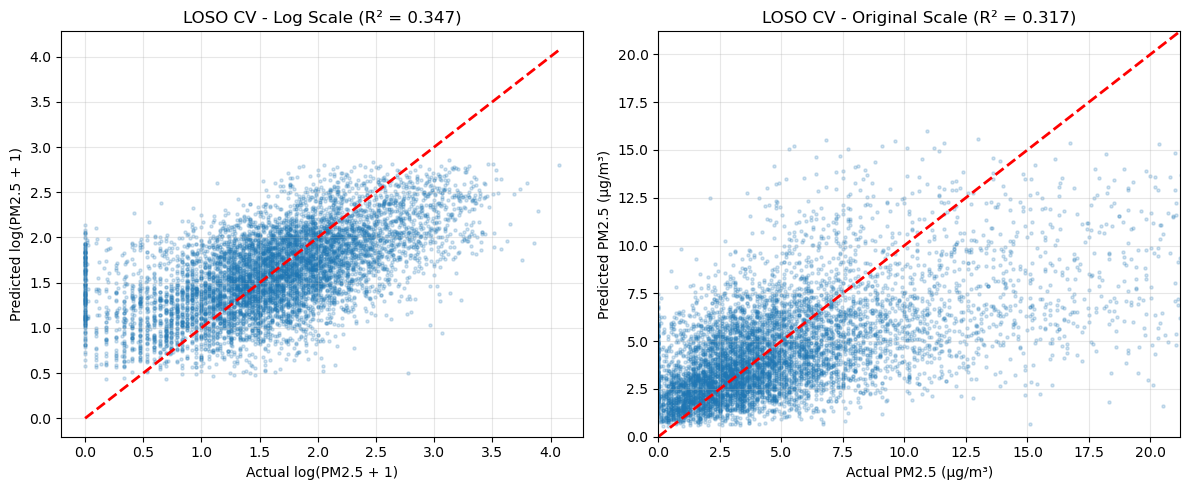

In [13]:
# Predictions vs Actual
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Log scale
axes[0].scatter(all_actuals, all_predictions, alpha=0.2, s=5)
axes[0].plot([all_actuals.min(), all_actuals.max()], 
             [all_actuals.min(), all_actuals.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual log(PM2.5 + 1)')
axes[0].set_ylabel('Predicted log(PM2.5 + 1)')
axes[0].set_title(f'LOSO CV - Log Scale (R² = {r2_log:.3f})')
axes[0].grid(True, alpha=0.3)

# Original scale
axes[1].scatter(actual_pm25, pred_pm25, alpha=0.2, s=5)
max_val = np.percentile(np.concatenate([actual_pm25, pred_pm25]), 99)
axes[1].plot([0, max_val], [0, max_val], 'r--', lw=2)
axes[1].set_xlabel('Actual PM2.5 (μg/m³)')
axes[1].set_ylabel('Predicted PM2.5 (μg/m³)')
axes[1].set_title(f'LOSO CV - Original Scale (R² = {r2_orig:.3f})')
axes[1].set_xlim(0, max_val)
axes[1].set_ylim(0, max_val)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

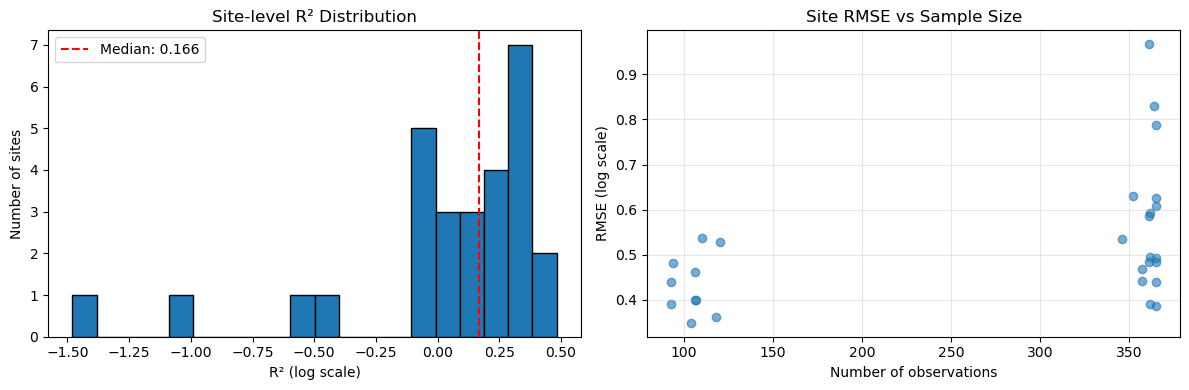

In [14]:
# Site-level R² distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# R² histogram
valid_r2 = metrics_df['r2_log'].dropna()
axes[0].hist(valid_r2, bins=20, edgecolor='black')
axes[0].axvline(x=valid_r2.median(), color='r', linestyle='--', label=f'Median: {valid_r2.median():.3f}')
axes[0].set_xlabel('R² (log scale)')
axes[0].set_ylabel('Number of sites')
axes[0].set_title('Site-level R² Distribution')
axes[0].legend()

# RMSE vs number of observations
axes[1].scatter(metrics_df['n_obs'], metrics_df['rmse_log'], alpha=0.6)
axes[1].set_xlabel('Number of observations')
axes[1].set_ylabel('RMSE (log scale)')
axes[1].set_title('Site RMSE vs Sample Size')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Best and worst performing sites
print("Top 5 best-performing sites (highest R²):")
print(metrics_df.nlargest(5, 'r2_log')[['site', 'n_obs', 'rmse_log', 'r2_log']].to_string(index=False))

print("\nTop 5 worst-performing sites (lowest R²):")
print(metrics_df.nsmallest(5, 'r2_log')[['site', 'n_obs', 'rmse_log', 'r2_log']].to_string(index=False))

Top 5 best-performing sites (highest R²):
        site  n_obs  rmse_log   r2_log
114001_45860    118  0.363119 0.482279
114270_47773     93  0.390524 0.384472
115553_48392    361  0.484968 0.382214
115672_47955    106  0.399913 0.368157
104476_48487    104  0.349249 0.366333

Top 5 worst-performing sites (lowest R²):
        site  n_obs  rmse_log    r2_log
111092_44658    361  0.966445 -1.479830
111056_45684    352  0.629194 -1.055588
106557_45648    120  0.529382 -0.536136
114021_46842    362  0.591666 -0.447532
112501_46003    365  0.787136 -0.105533


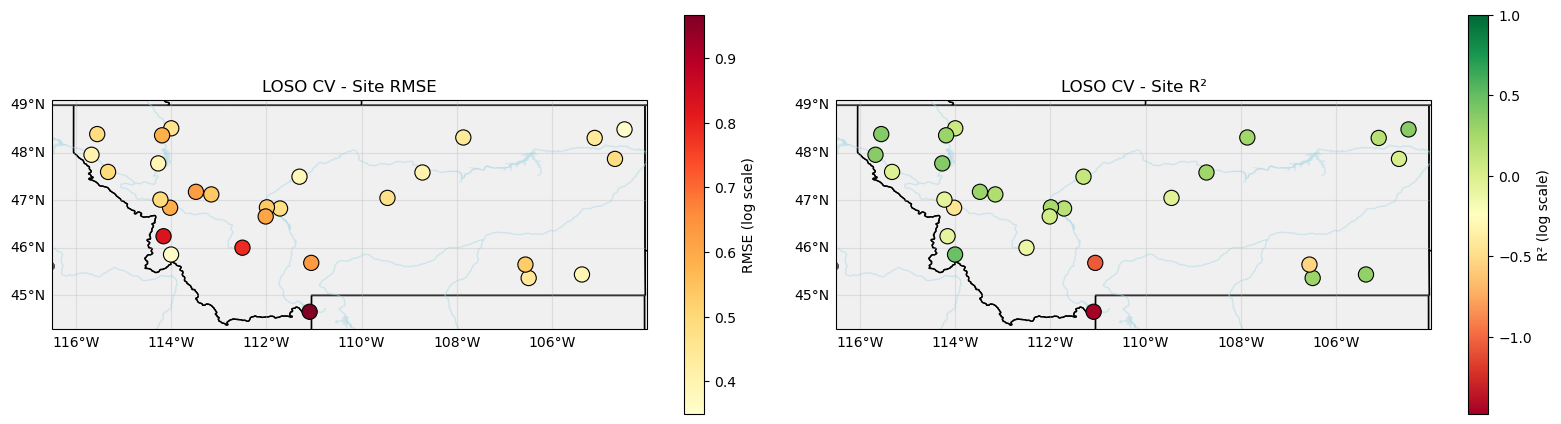

In [16]:
# Map of site-level error on Montana map
site_coords = df_clean.groupby('ll_id')[['lat', 'lon']].first().reset_index()
site_with_error = site_coords.merge(metrics_df[['site', 'rmse_log', 'r2_log']], 
                                     left_on='ll_id', right_on='site', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                          subplot_kw={'projection': ccrs.PlateCarree()})

for ax in axes:
    ax.set_extent([-116.5, -104.0, 44.3, 49.1], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=1.0)
    ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
    ax.add_feature(cfeature.LAKES, facecolor='lightblue', alpha=0.5)
    ax.add_feature(cfeature.RIVERS, edgecolor='lightblue', alpha=0.5)

# RMSE map
sc1 = axes[0].scatter(site_with_error['lon'], site_with_error['lat'],
                       c=site_with_error['rmse_log'], cmap='YlOrRd', 
                       s=120, edgecolors='black', linewidth=0.8,
                       transform=ccrs.PlateCarree(), zorder=5)
plt.colorbar(sc1, ax=axes[0], label='RMSE (log scale)', shrink=0.7)
axes[0].set_title('LOSO CV - Site RMSE')
gl0 = axes[0].gridlines(draw_labels=True, alpha=0.3)
gl0.top_labels = False
gl0.right_labels = False

# R² map
r2_min = min(0, site_with_error['r2_log'].min())
sc2 = axes[1].scatter(site_with_error['lon'], site_with_error['lat'],
                       c=site_with_error['r2_log'], cmap='RdYlGn', 
                       s=120, edgecolors='black', linewidth=0.8,
                       vmin=r2_min, vmax=1,
                       transform=ccrs.PlateCarree(), zorder=5)
plt.colorbar(sc2, ax=axes[1], label='R² (log scale)', shrink=0.7)
axes[1].set_title('LOSO CV - Site R²')
gl1 = axes[1].gridlines(draw_labels=True, alpha=0.3)
gl1.top_labels = False
gl1.right_labels = False

plt.tight_layout()
plt.show()

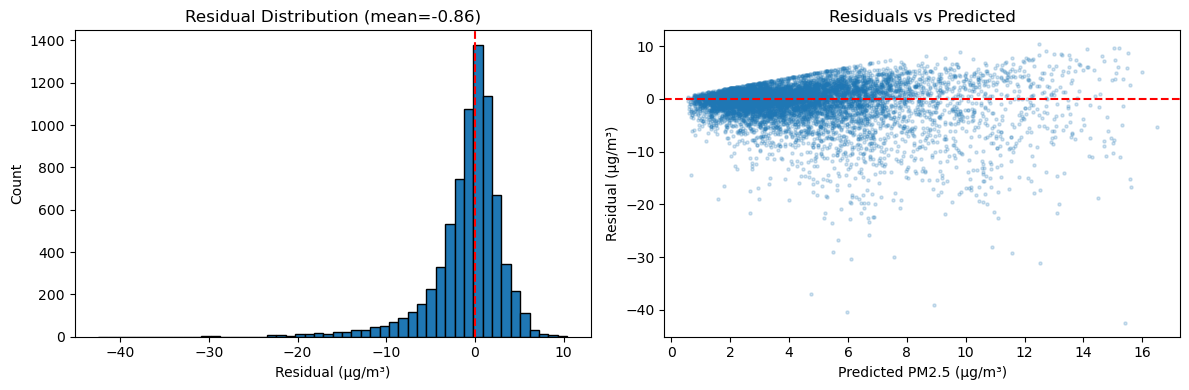

In [17]:
# Residual analysis
residuals = pred_pm25 - actual_pm25

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuals, bins=50, edgecolor='black')
axes[0].axvline(x=0, color='r', linestyle='--')
axes[0].set_xlabel('Residual (μg/m³)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Residual Distribution (mean={residuals.mean():.2f})')

axes[1].scatter(pred_pm25, residuals, alpha=0.2, s=5)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted PM2.5 (μg/m³)')
axes[1].set_ylabel('Residual (μg/m³)')
axes[1].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()

## 6. Save Results

In [18]:
import os
# Save site-level metrics
metrics_df['years'] = '2019'
if os.path.exists('../results/loso_site_metrics.csv'):
    existing = pd.read_csv('../results/loso_site_metrics.csv')
    pd.concat([existing, metrics_df], ignore_index=True).to_csv('../results/loso_site_metrics.csv', index=False)
else:
    metrics_df.to_csv('../results/loso_site_metrics.csv', index=False)
print("Site metrics saved to results/loso_site_metrics.csv")

# Save overall results
results = {
    'years': '2019',
    'cv_method': 'LOSO',
    'n_sites': n_sites,
    'n_predictions': len(all_predictions),
    'rmse_log': rmse_log,
    'mae_log': mae_log,
    'r2_log': r2_log,
    'rmse_orig': rmse_orig,
    'mae_orig': mae_orig,
    'r2_orig': r2_orig,
    'total_time_seconds': cv_total_time
}
new_row = pd.DataFrame([results])
if os.path.exists('../results/loso_overall_results.csv'):
    existing = pd.read_csv('../results/loso_overall_results.csv')
    pd.concat([existing, new_row], ignore_index=True).to_csv('../results/loso_overall_results.csv', index=False)
else:
    new_row.to_csv('../results/loso_overall_results.csv', index=False)
print("Overall results saved to results/loso_overall_results.csv")

# Save fold-level timing
timing_df = pd.DataFrame(fold_timings)
timing_df['years'] = '2019'
if os.path.exists('../timings/loso_fold_timings.csv'):
    existing = pd.read_csv('../timings/loso_fold_timings.csv')
    pd.concat([existing, timing_df], ignore_index=True).to_csv('../timings/loso_fold_timings.csv', index=False)
else:
    timing_df.to_csv('../timings/loso_fold_timings.csv', index=False)
print("Fold timings saved to timings/loso_fold_timings.csv")

# Timing summary
print("\n" + "=" * 50)
print("Timing Summary")
print("=" * 50)
print(f"Total CV time: {cv_total_time:.1f}s ({cv_total_time/60:.1f} min)")
print(f"\nPer-fold timing (across {len(timing_df)} folds):")
print(f"  Training:  mean={timing_df['train_time'].mean():.2f}s, std={timing_df['train_time'].std():.2f}s")
print(f"  Inference: mean={timing_df['infer_time'].mean():.3f}s, std={timing_df['infer_time'].std():.3f}s")
print(f"  Total:     mean={timing_df['fold_time'].mean():.2f}s, std={timing_df['fold_time'].std():.2f}s")

# Show timing logger summary
timing_log.summary()

Site metrics saved to results/loso_site_metrics.csv
Overall results saved to results/loso_overall_results.csv
Fold timings saved to timings/loso_fold_timings.csv

Timing Summary
Total CV time: 49.3s (0.8 min)

Per-fold timing (across 28 folds):
  Training:  mean=1.66s, std=0.23s
  Inference: mean=0.088s, std=0.003s
  Total:     mean=1.76s, std=0.28s

Timing Summary: ../timings/gpr_timings.csv

training:
  Count: 4
  Mean:  3.126s
  Std:   0.168s
  Min:   2.935s
  Max:   3.316s

inference:
  Count: 4
  Mean:  0.081s
  Std:   0.003s
  Min:   0.079s
  Max:   0.085s

loso_cv_total:
  Count: 5
  Mean:  44.333s
  Std:   3.186s
  Min:   41.389s
  Max:   49.344s

spatial_cv_total:
  Count: 2
  Mean:  9.353s
  Std:   1.228s
  Min:   8.485s
  Max:   10.221s


,timestamp,experiment,operation,n_train,n_features,n_epochs,kernel,elapsed_seconds,n_test,batch_size,n_folds,years
0,2026-02-08T19:35:27.914688,baseline_random_split,training,2000.0,16,100.0,RBF_ARD,3.048240,NaN,NaN,NaN,2019
1,2026-02-08T19:35:31.067357,baseline_random_split,inference,2000.0,16,NaN,NaN,0.079156,1511.0,500.0,NaN,2019
2,2026-02-08T19:36:36.901326,loso_cv,loso_cv_total,NaN,16,50.0,NaN,45.539098,NaN,NaN,28.0,2019
3,2026-02-08T19:37:05.013040,spatial_cv,spatial_cv_total,NaN,16,50.0,NaN,8.484749,NaN,NaN,5.0,2019
4,2026-02-10T14:45:12.636565,baseline_random_split,training,2000.0,16,100.0,RBF_ARD,3.316486,NaN,NaN,NaN,2019
5,2026-02-10T14:45:16.055818,baseline_random_split,inference,2000.0,16,NaN,NaN,0.080925,1511.0,500.0,NaN,2019
6,2026-02-10T18:55:48.904301,loso_cv,loso_cv_total,NaN,16,50.0,NaN,41.388759,NaN,NaN,28.0,2019
7,2026-02-10T19:18:24.395793,baseline_random_split,training,2000.0,16,100.0,RBF_ARD,2.934810,NaN,NaN,NaN,2018-2019
8,2026-02-10T19:18:27.423776,baseline_random_split,inference,2000.0,16,NaN,NaN,0.085181,3016.0,500.0,NaN,2018-2019
9,2026-02-10T19:19:45.717205,loso_cv,loso_cv_total,NaN,16,50.0,NaN,42.562510,NaN,NaN,28.0,2018-2019


## Summary

LOSO CV provides a more realistic estimate of model performance for predicting at new, unmonitored locations. The R² is typically lower than random split because:

1. No information from the test site is used during training
2. Spatial heterogeneity makes prediction at new locations harder
3. Some sites may have unique characteristics not captured by covariates